# **Apply Feature Importance to Telecom Churn Project**

In [1]:
import pandas as pd

# Load your dataset (adjust the filename to match your dataset)
data = pd.read_csv('/content/customer_churnfinal.csv')

# Preview the first few rows of the dataset
print(data.head())


  Customer ID  Gender  Age Married  Tenure in Months    Offer Phone Service  \
0  0002-ORFBO  Female   37     Yes                 9      NaN           Yes   
1  0003-MKNFE    Male   46      No                 9      NaN           Yes   
2  0004-TLHLJ    Male   50      No                 4  Offer E           Yes   
3  0011-IGKFF    Male   78     Yes                13  Offer D           Yes   
4  0013-EXCHZ  Female   75     Yes                 3      NaN           Yes   

   Avg Monthly Long Distance Charges Multiple Lines Internet Service  ...  \
0                              42.39             No              Yes  ...   
1                              10.69            Yes              Yes  ...   
2                              33.65             No              Yes  ...   
3                              27.82             No              Yes  ...   
4                               7.38             No              Yes  ...   

  Streaming TV  Streaming Movies Streaming Music Unlimited Dat

In [9]:
# Select the features (independent variables)
features = ['Monthly Charge', 'Contract', 'Tenure in Months', 'Age', 'Total Charges']  # Add more relevant features

# Target variable (dependent variable) - Churn status
target = 'CustomerStatus'

# Create feature matrix (X) and target vector (y)
X = data[features]
y = data[target]

# Print the shapes to confirm everything is correct
print(X.shape, y.shape)


(1000, 5) (1000,)


In [10]:
# One-Hot Encoding for categorical features (e.g., ContractType)
X_encoded = pd.get_dummies(X, drop_first=True)

# Print the first few rows of the encoded feature matrix
print(X_encoded.head())


   Monthly Charge  Tenure in Months  Age  Total Charges  Contract_One Year  \
0            65.6                 9   37         593.30               True   
1            -4.0                 9   46         542.40              False   
2            73.9                 4   50         280.85              False   
3            98.0                13   78        1237.85              False   
4            83.9                 3   75         267.40              False   

   Contract_Two Year  
0              False  
1              False  
2              False  
3              False  
4              False  


In [11]:

from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Print the shapes of the training and testing sets
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(800, 6) (200, 6) (800,) (200,)


In [12]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [13]:
# Get feature importance scores
importances = model.feature_importances_

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Print the feature importance
print(feature_importance_df)


             Feature  Importance
3      Total Charges    0.264548
1   Tenure in Months    0.252594
0     Monthly Charge    0.225842
2                Age    0.158436
5  Contract_Two Year    0.067032
4  Contract_One Year    0.031547


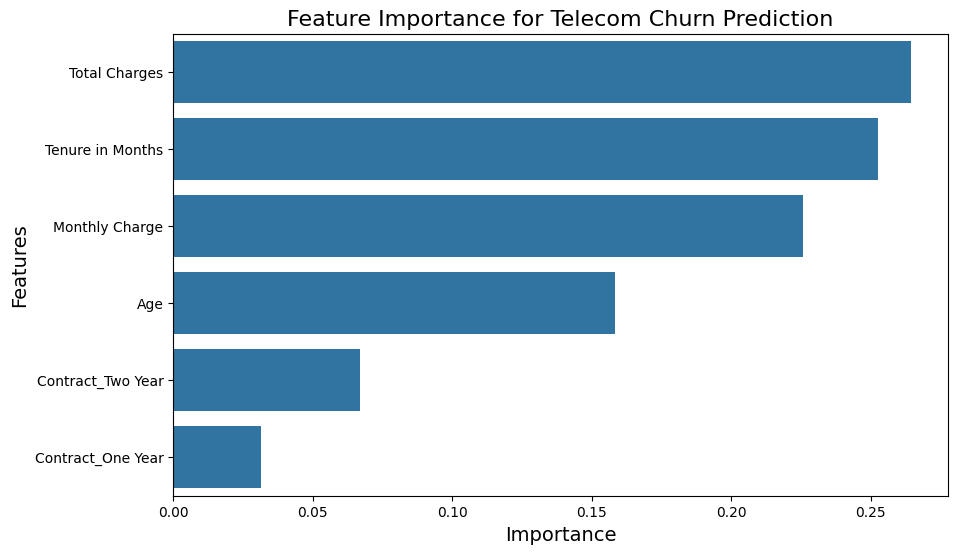

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)

# Add titles and labels
plt.title('Feature Importance for Telecom Churn Prediction', fontsize=16)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Features', fontsize=14)

# Show the plot
plt.show()
